In [1]:
import argparse
import sys
import os
from pathlib import Path

import h5py
import numpy as np
from scipy.stats import qmc

sys.path.insert(0, "TelFit/src")
from telfit import Modeler
import importlib
import MakeModel
importlib.reload(MakeModel)

import time
from matplotlib import pyplot as plt



modeler = Modeler()

/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# === Configuration ===
PARAM_RANGES = {
    "pressure": (750, 850),  # hPa
    "temperature": (270, 300),  # Kelvin
    "angle": (5, 60),  # zenith distance (degrees)
    "humidity": (10, 90),  # percent
    "co2": (350, 450),  # ppmv
    "o3": (0.02, 0.08),  # ppmv
    "n2o": (0.30, 0.35),  # ppmv
    "co": (0.05, 0.30),  # ppmv
    "ch4": (1.7, 2.1),  # ppmv
    "o2": (209000, 210000),  # ppmv
    "no": (1e-5, 1e-3),  # ppmv
    "so2": (1e-5, 1e-3),  # ppmv
    "no2": (1e-5, 1e-3),  # ppmv
    "nh3": (1e-5, 1e-3),  # ppmv
    "hno3": (1e-4, 1e-3),  # ppmv
}

FIXED_PARAMS = {
    "lat": 30.6,
    "alt": 2.1,
}

WAVESTART_NM = 500.0
# WAVEEND_NM = 1800.0

# STELLAR_H5 = Path("/home/ubuntu/Tellurics/Phoenix/phoenix_spectra.h5")
# OUTDIR = Path("/home/ubuntu/Tellurics/TelFit/telluric_templates")

STELLAR_H5 = Path("/home/mvasist/Documents/Tellurics/Phoenix/phoenix_spectra.h5")
OUTDIR = Path("/home/mvasist/Documents/Tellurics/TelFit/telluric_templates")

CHUNKS_DIR = OUTDIR / "chunks"

param_names = list(PARAM_RANGES.keys())
bounds_low = [v[0] for v in PARAM_RANGES.values()]
bounds_high = [v[1] for v in PARAM_RANGES.values()]


samples_unit = qmc.LatinHypercube(d=len(param_names), seed=42).random(n=10)
samples = qmc.scale(samples_unit, bounds_low, bounds_high)
params = dict(zip(param_names, samples))


In [3]:
params_one = dict(zip(param_names, np.round(samples[0], 2).astype(float)))  # Use the first sample for testing
params_one_ = dict(zip(param_names, samples[0]))  # Use the first sample for testing

In [4]:
def get_stellar_wavegrid():
    """Load the stellar wavelength grid (in um)."""
    with h5py.File(STELLAR_H5, "r") as hf:
        return hf["wavelengths"][0].astype(np.float32)  # (D,) in um

    # with h5py.File(STELLAR_H5, "r") as hf:
    #     print(list(hf.keys()))
    #     print(hf["wavelengths"][:].shape)
    #     print(hf["flux"][:].shape)
    #     print(hf["labels"][:].shape)
    #     print(hf["labels"].attrs["columns"])

    # return hf["wavelengths"][:].astype(np.float32)  # (D,) in um


# Load stellar wavegrid
stellar_wavegrid_nm = get_stellar_wavegrid()

print(stellar_wavegrid_nm.shape, " see this first")


(19214,)  see this first


In [5]:
# model = modeler.MakeModel(
#                 lowfreq=1e7 / WAVEEND_NM,
#                 highfreq=1e7 / WAVESTART_NM,
#                 wavegrid=wavegrid_nm,
#                 **params_one,
#                 **FIXED_PARAMS,
#             )

In [6]:
params_one, params_one_

({'pressure': 832.26,
  'temperature': 280.68,
  'angle': 5.78,
  'humidity': 28.42,
  'co2': 379.06,
  'o3': 0.04,
  'n2o': 0.3,
  'co': 0.23,
  'ch4': 1.93,
  'o2': 209354.96,
  'no': 0.0,
  'so2': 0.0,
  'no2': 0.0,
  'nh3': 0.0,
  'hno3': 0.0},
 {'pressure': 832.2604395144403,
  'temperature': 280.68336468074386,
  'angle': 5.777711440487397,
  'humidity': 28.42105576752509,
  'co2': 379.0582265211235,
  'o3': 0.03814626589017947,
  'n2o': 0.3011943014900482,
  'co': 0.23034839236807614,
  'ch4': 1.9348754546929783,
  'o2': 209354.96140621044,
  'no': 0.0005672909956009745,
  'so2': 0.0007102502661039885,
  'no2': 0.0008372573531120141,
  'nh3': 2.7546600286187833e-05,
  'hno3': 0.0005100927221055403})

In [7]:
stellar_wavegrid_nm

array([ 500.00745,  500.0408 ,  500.07413, ..., 1799.6659 , 1799.7859 ,
       1799.9059 ], dtype=float32)


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
21.06user 2.60system 0:23.87elapsed 99%CPU (0avgtext+0avgdata 7296maxresident)k
68184inputs+1909016outputs (26major+1091minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
10.99user 2.23system 0:13.38elapsed 98%CPU (0avgtext+0avgdata 7680maxresident)k
3208inputs+1532432outputs (0major+1102minor)pagefaults 0swaps



Running exec: lblrtm




...


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
2.19user 1.61system 0:04.15elapsed 91%CPU (0avgtext+0avgdata 7680maxresident)k
0inputs+707320outputs (0major+1092minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.86user 1.23system 0:02.10elapsed 99%CPU (0avgtext+0avgdata 7680maxresident)k
0inputs+153776outputs (0major+1084minor)pagefaults 0swaps


Warning, 14007 of 5993700 bins contained negative fluxes; they have been set to zero.
OK: 19214 points
Model time: 89.45538926124573


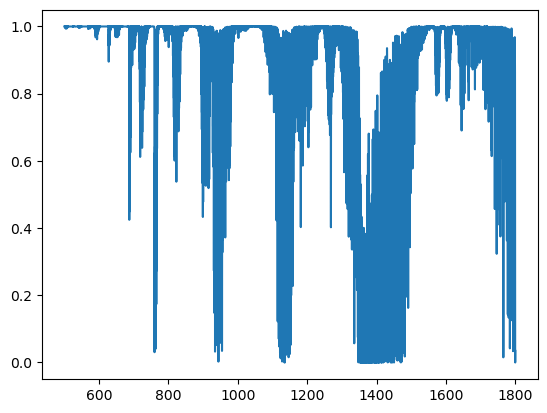

In [9]:
m = Modeler()
start = time.time()
model = m.MakeModel(lowfreq=1e7/1800, highfreq=1e7/500, \
                    wavegrid=stellar_wavegrid_nm, **FIXED_PARAMS, **params_one) 
print(f'OK: {len(model.x)} points')
end = time.time()

print(f'Model time: {end-start}')

plt.plot(model.x, model.y)
plt.show()

In [ ]:
model = m.MakeModel(lowfreq=1e7/1800, highfreq=1e7/500, \
                    wavegrid=wavegrid_nm, **FIXED_PARAMS, **params_one_)
print(f'OK: {len(model.x)} points')

plt.plot(model.x, model.y)
plt.show()